In [217]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys


Estimated Plot

In [218]:
samples = 500
time = np.linspace(0,samples,samples)
velocity = []
i=0
while i < len(time):
    v = 2*time[i]+17
    velocity.append(v)
    i +=1



Noise Signal

In [219]:
noiseSignal_1  = np.random.normal(np.mean(velocity)*.7,7,samples)
noiseSignal_2  = np.random.normal(np.mean(velocity)*4,7,samples)


Measure Signal

In [220]:
measuredSignal_1 = velocity+noiseSignal_1
measuredSignal_2 = velocity+noiseSignal_2



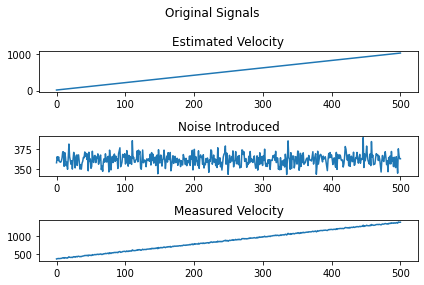

In [221]:
fig, (ax1, ax2,ax3) = plt.subplots(3, 1)
fig.suptitle('Original Signals')
ax1.plot(time,velocity)
ax1.set_title("Estimated Velocity")
ax2.set_title("Noise Introduced")
ax3.set_title("Measured Velocity")
ax2.plot(time,noiseSignal_1)
ax3.plot(time,measuredSignal_1)
fig.tight_layout()
plt.show()

In [222]:
R = np.var(measuredSignal_1)
H = 1
Q = 2*(time[1]-time[0])
B = 0
F =1
i = 0
v = 17
output = []
P = 1e+5



In [223]:
while i < len(time):   
    v = F * v
    P = P + Q
    K = P/(P+R)
    v = v + K*(measuredSignal_1[i]-v)
    P = P*(1- K)
    output.append(v)
    i += 1
    

print(output[0])      



211.97301325353058


False


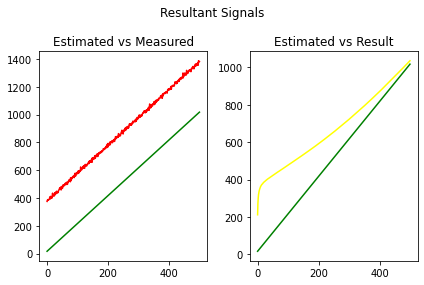

In [224]:
print(np.any(output == velocity))
fig, (ax1, ax2,) = plt.subplots(1, 2)
fig.suptitle('Resultant Signals')
ax2.plot(time,velocity,'green')
ax2.plot(time,output,'yellow')
ax2.set_title("Estimated vs Result")
ax1.set_title("Estimated vs Measured")
ax1.plot(time,velocity,'green')
ax1.plot(time,measuredSignal_1,'red')
fig.tight_layout()
plt.show()

[array([0.085107  , 0.08726302, 0.08674493, 0.08812522, 0.08726363,
       0.08763771, 0.08797595, 0.08876718, 0.09003997, 0.09225318,
       0.09275594, 0.0891138 , 0.09339029, 0.09257744, 0.09063387,
       0.09209386, 0.0905451 , 0.09421853, 0.09854483, 0.09547064,
       0.09486554, 0.09423093, 0.09566091, 0.0937798 , 0.09694745,
       0.09938803, 0.09854686, 0.09593347, 0.09911382, 0.10045531,
       0.09798816, 0.10136916, 0.10184817, 0.10015191, 0.09878498,
       0.10048223, 0.09967639, 0.10177263, 0.10277451, 0.10432473,
       0.10464629, 0.10676215, 0.10603558, 0.1072757 , 0.10602114,
       0.10803007, 0.10375161, 0.10942222, 0.10728116, 0.1084389 ,
       0.10626302, 0.10723753, 0.11197584, 0.10955191, 0.10972259,
       0.11207779, 0.11259847, 0.11104028, 0.11305444, 0.1131084 ,
       0.11487341, 0.11241892, 0.11370951, 0.11550251, 0.11634895,
       0.11271588, 0.11415111, 0.11313942, 0.11640809, 0.11758036,
       0.1170733 , 0.11987781, 0.11842128, 0.11845714, 0.1203

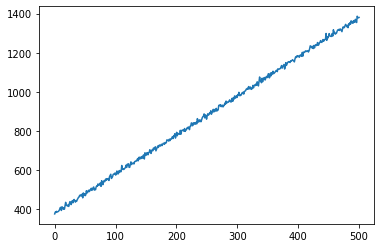

In [225]:

from matplotlib.cbook import print_cycles


def KalmanFilter(R,H,Q,B,F,P,*sensors):
    i = 0
    v = 0
    output = [] 
    while i<len(sensors):
        v,P =Predict(v,P)       
        v,P = Update(v,P,R,sensors[i])            
        output.append(v)
        i +=1
    print(output)
    return output

def Predict(v,P):
    v = F * v
    P = P + Q
    return v,P
def Update(v,P,R,signal):
    K = P/(P+R)
    v = v + K*(signal)
    P = P*(1- K)
    return v,P

#R = np.array([np.var(measuredSignal_1),np.var(measuredSignal_2)])

H = 1
Q = 2*(time[1]-time[0])
B = 0
F =1
i = 0
v = 17
output = []
P = 17

y = KalmanFilter(R,H,Q,B,F,P,measuredSignal_1)

plt.plot(time,measuredSignal_1)
#plt.plot(time,y)
plt.show()


In [226]:
R = np.array([np.var(measuredSignal_1),np.var(measuredSignal_2)])
i = 0
Update(v,P,R,measuredSignal_1,i)

TypeError: Update() takes 4 positional arguments but 5 were given